In [ ]:
#MATH 516

In [ ]:
#IMPORTS

In [2]:
import sys
!"{sys.executable}" -m pip install xgboost xlrd imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [1]:
#INSTALLING ALL PACKAGES
!pip install xgboost
!pip install xlrd
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline

# Feature selection
from sklearn.feature_selection import (RFE, mutual_info_classif,
                                       SelectFromModel)
from sklearn.linear_model import LassoCV, LogisticRegression

# Classifiers
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             f1_score, recall_score, precision_score)
from sklearn.preprocessing import label_binarize

# Plotting style
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
All imports successful.


In [ ]:
# 1. DATA LOADING

In [2]:
#LOAD CTG DATASET CORRECTLY
import pandas as pd
import numpy as np

# Read the correct sheet
df = pd.read_excel(
    "CTG.xls",
    sheet_name="Raw Data",
    engine="xlrd"
)

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Original shape: (2130, 40)

Columns:
['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS', 'NSP']


In [3]:
#Keep only columns used in the coursework
feature_cols = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP',
    'ASTV', 'MSTV', 'ALTV', 'MLTV',
    'Width', 'Min', 'Max', 'Nmax', 'Nzeros',
    'Mode', 'Mean', 'Median', 'Variance', 'Tendency'
]

target_col = 'NSP'

# Remove rows with missing target
df = df.dropna(subset=[target_col]).copy()

# Create feature matrix and target
X = df[feature_cols].copy()
y_multi = df[target_col].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y_multi.shape)
print("\nFirst 5 rows:")
print(X.head())

Feature matrix shape: (2126, 21)
Target shape: (2126,)

First 5 rows:
      LB   AC   FM   UC   DL   DS   DP  ASTV  MSTV  ALTV  ...  Width   Min  \
1  120.0  0.0  0.0  0.0  0.0  0.0  0.0  73.0   0.5  43.0  ...   64.0  62.0   
2  132.0  4.0  0.0  4.0  2.0  0.0  0.0  17.0   2.1   0.0  ...  130.0  68.0   
3  133.0  2.0  0.0  5.0  2.0  0.0  0.0  16.0   2.1   0.0  ...  130.0  68.0   
4  134.0  2.0  0.0  6.0  2.0  0.0  0.0  16.0   2.4   0.0  ...  117.0  53.0   
5  132.0  4.0  0.0  5.0  0.0  0.0  0.0  16.0   2.4   0.0  ...  117.0  53.0   

     Max  Nmax  Nzeros   Mode   Mean  Median  Variance  Tendency  
1  126.0   2.0     0.0  120.0  137.0   121.0      73.0       1.0  
2  198.0   6.0     1.0  141.0  136.0   140.0      12.0       0.0  
3  198.0   5.0     1.0  141.0  135.0   138.0      13.0       0.0  
4  170.0  11.0     0.0  137.0  134.0   137.0      13.0       1.0  
5  170.0   9.0     0.0  137.0  136.0   138.0      11.0       1.0  

[5 rows x 21 columns]


In [4]:
#cLASSIFICATION
label_map = {
    1: "Normal",
    2: "Suspect",
    3: "Pathologic"
}

print("\nClass distribution:")
counts = y_multi.value_counts().sort_index()

for cls, cnt in counts.items():
    pct = 100 * cnt / len(y_multi)
    print(f"Class {cls} ({label_map[cls]}): {cnt} ({pct:.1f}%)")


Class distribution:
Class 1 (Normal): 1655 (77.8%)
Class 2 (Suspect): 295 (13.9%)
Class 3 (Pathologic): 176 (8.3%)


In [6]:
#EXPLORATORY DATA ANALYSIS
print("\n" + "="*60)
print("2. EXPLORATORY DATA ANALYSIS")
print("="*60)

print(f"\nFeature names ({len(X.columns)}):")
print(X.columns.tolist())

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"\nBasic statistics:")
print(X.describe().round(2))
y_binary = (y_multi == 1).astype(int)


2. EXPLORATORY DATA ANALYSIS

Feature names (21):
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

Missing values: 0

Basic statistics:
            LB       AC       FM       UC       DL       DS       DP     ASTV  \
count  2126.00  2126.00  2126.00  2126.00  2126.00  2126.00  2126.00  2126.00   
mean    133.30     2.72     7.24     3.66     1.57     0.00     0.13    46.99   
std       9.84     3.56    37.13     2.85     2.50     0.06     0.46    17.19   
min     106.00     0.00     0.00     0.00     0.00     0.00     0.00    12.00   
25%     126.00     0.00     0.00     1.00     0.00     0.00     0.00    32.00   
50%     133.00     1.00     0.00     3.00     0.00     0.00     0.00    49.00   
75%     140.00     4.00     2.00     5.00     3.00     0.00     0.00    61.00   
max     160.00    26.00   564.00    23.00    16.00     1.00     4.00    87.00   

          MSTV 

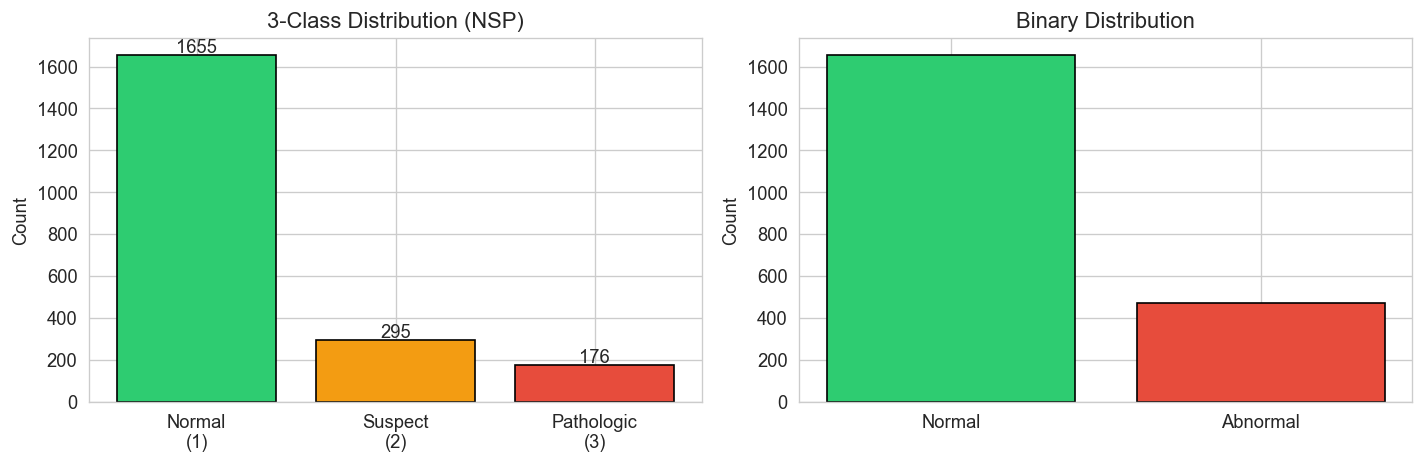

In [7]:
#VISUALIZATION OF THE DISTRIBUTIONS; NSP AND BINARY
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3-class
colors_3 = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(
    ['Normal\n(1)', 'Suspect\n(2)', 'Pathologic\n(3)'],
    counts.values,
    color=colors_3,
    edgecolor='black'
)
axes[0].set_title('3-Class Distribution (NSP)')
axes[0].set_ylabel('Count')

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Binary
axes[1].bar(
    ['Normal', 'Abnormal'],
    [y_binary.sum(), (y_binary == 0).sum()],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[1].set_title('Binary Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

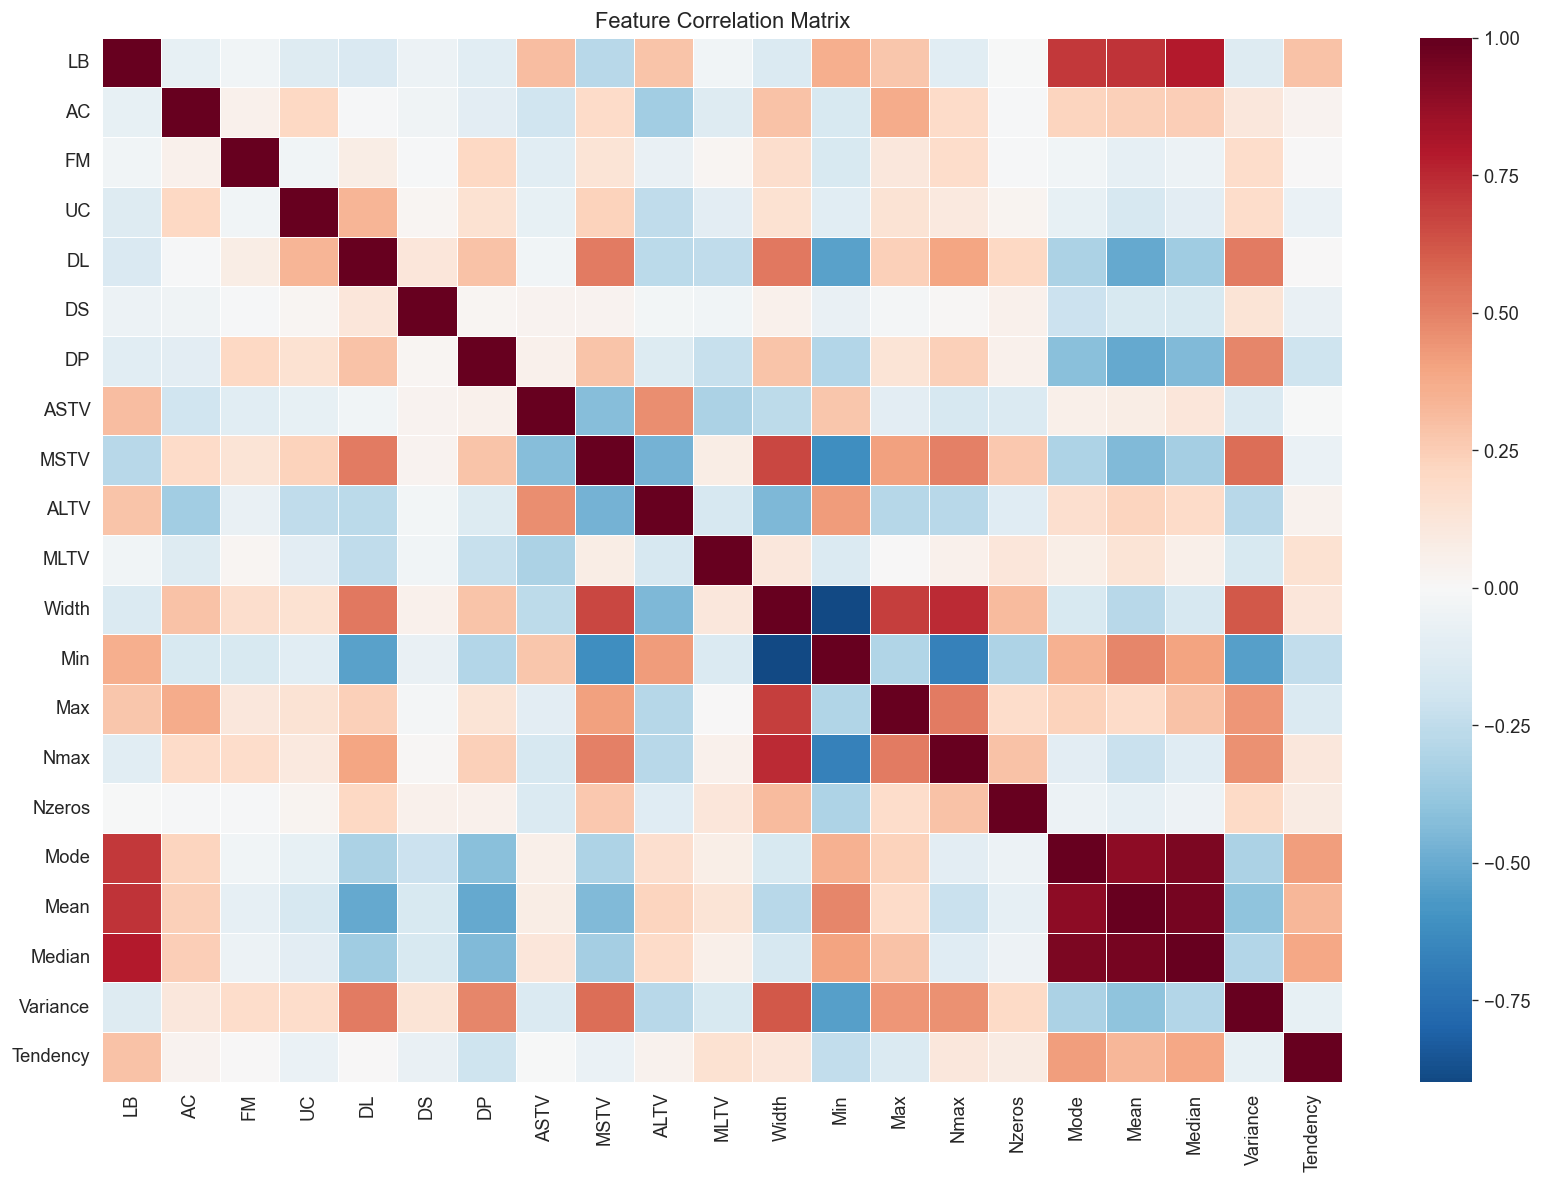

In [8]:
#correlation heatmap
plt.figure(figsize=(14, 10))

corr_matrix = X.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    linewidths=0.3
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

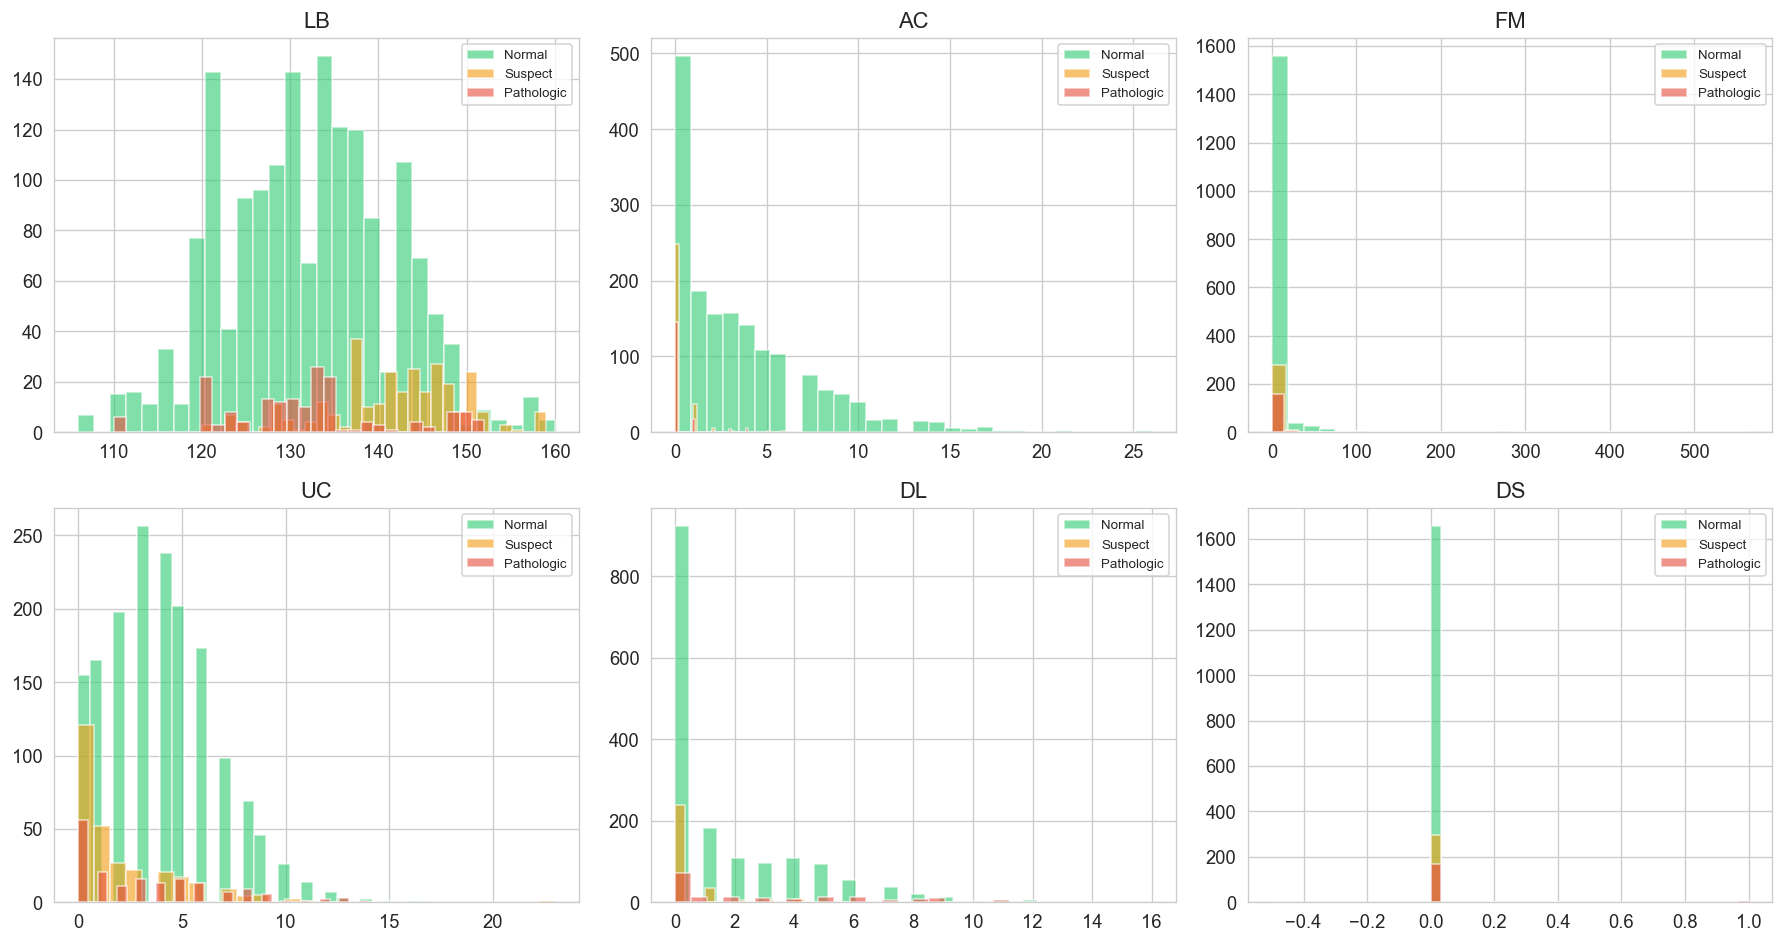

In [9]:
#distribution by class
label_map = {
    1: 'Normal',
    2: 'Suspect',
    3: 'Pathologic'
}
#top 6 features
key_features = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS'] 

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

X_plot = X.copy()
X_plot['Class'] = y_multi.map(label_map)

for i, feat in enumerate(key_features):
    for cls, color in zip(
        ['Normal', 'Suspect', 'Pathologic'],
        ['#2ecc71', '#f39c12', '#e74c3c']
    ):
        subset = X_plot[X_plot['Class'] == cls][feat]

        axes[i].hist(
            subset,
            bins=30,
            alpha=0.6,
            label=cls,
            color=color
        )

    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
#PREPROCESSING OF THE DATA

In [11]:
# Remove missing rows
X_clean = X.dropna().copy()
y_multi_clean = y_multi.loc[X_clean.index].copy()
y_binary_clean = y_binary.loc[X_clean.index].copy()

print(f"Samples after dropping NaN: {len(X_clean)}")

# Encode multiclass labels for ML models
y_multi_encoded = y_multi_clean - 1

# Train-test split (80/20 stratified)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_clean,
    y_multi_encoded,
    test_size=0.2,
    stratify=y_multi_encoded,
    random_state=RANDOM_STATE
    )

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_clean,
    y_binary_clean,
    test_size=0.2,
    stratify=y_binary_clean,
    random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train_m)}")
print(f"Test size: {len(X_test_m)}")

# Scale multiclass features to avloid data leakage
scaler_m = StandardScaler()
X_train_scaled_m = scaler_m.fit_transform(X_train_m)
X_test_scaled_m = scaler_m.transform(X_test_m)

# Scale binary features
scaler_b = StandardScaler()
X_train_scaled_b = scaler_b.fit_transform(X_train_b)
X_test_scaled_b = scaler_b.transform(X_test_b)

print("Scaling complete.")

Samples after dropping NaN: 2126
Train size: 1700
Test size: 426
Scaling complete.


In [12]:
#ADDRESSING CLASS IMBALANCE USING SMOTE

In [13]:
print("="*60)
print("4. CLASS IMBALANCE — SMOTE")
print("="*60)

#k_neiggbors =3 helps reduce the risk for generating noisy synthetic points
#as the smallest class(pathologic) is relatively small
smote = SMOTE(k_neighbors=3, random_state=RANDOM_STATE)

# Multiclass
X_train_sm, y_train_sm = smote.fit_resample(
    X_train_scaled_m,
    y_train_m
)

print("\nMulticlass — After SMOTE:")
for cls, name in enumerate(['Normal', 'Suspect', 'Pathologic']):
    print(f"{name}: {(y_train_sm == cls).sum()}")

# Binary
X_train_sm_b, y_train_sm_b = smote.fit_resample(
    X_train_scaled_b,
    y_train_b
)

print("\nBinary — After SMOTE:")
print(f"Normal   : {(y_train_sm_b == 1).sum()}")
print(f"Abnormal : {(y_train_sm_b == 0).sum()}")

4. CLASS IMBALANCE — SMOTE

Multiclass — After SMOTE:
Normal: 1323
Suspect: 1323
Pathologic: 1323

Binary — After SMOTE:
Normal   : 1323
Abnormal : 1323


In [14]:
#FEATURE SELECTION
#Methods: Mutual Information | RFE | LASSO

In [15]:
print("="*60)
print("5. FEATURE SELECTION")
print("="*60)

feature_names = X_clean.columns.tolist()


# 5a. Mutual Information
# =========================
mi_scores = mutual_info_classif(
    X_train_sm,
    y_train_sm,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop MI features:")  #TOP FEATURES FOR MUTUAL INFORMATION
print(mi_df.head(10))

5. FEATURE SELECTION

Top MI features:
     Feature  MI_Score
17      Mean  0.592680
18    Median  0.578902
8       MSTV  0.575193
16      Mode  0.518748
9       ALTV  0.483738
10      MLTV  0.479630
7       ASTV  0.475204
11     Width  0.463924
19  Variance  0.460931
0         LB  0.420057


In [16]:
# 5b. RFE
rf_rfe = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rfe = RFE(
    estimator=rf_rfe,
    n_features_to_select=10
)

rfe.fit(X_train_sm, y_train_sm)

rfe_selected = [
    f for f, s in zip(feature_names, rfe.support_) if s
]

rfe_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Rank': rfe.ranking_
}).sort_values('Rank')

print("\nRFE selected:")
print(rfe_selected)


RFE selected:
['LB', 'AC', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Mode', 'Mean', 'Median']


In [17]:
# 5c. LASSO
lasso_lr = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.1,
    max_iter=5000,
    random_state=RANDOM_STATE,
    multi_class='multinomial'
)

lasso_lr.fit(X_train_sm, y_train_sm)

coef_sum = np.abs(lasso_lr.coef_).sum(axis=0)

lasso_df = pd.DataFrame({
    'Feature': feature_names,
    'LASSO_Coef': coef_sum
}).sort_values('LASSO_Coef', ascending=False)

lasso_selected = lasso_df[lasso_df['LASSO_Coef'] > 0]['Feature'].tolist()

print("\nLASSO selected:")
print(lasso_selected)


LASSO selected:
['AC', 'ASTV', 'LB', 'Median', 'Mean', 'Variance', 'DP', 'ALTV', 'MSTV', 'Nmax', 'Mode', 'FM', 'UC', 'Max', 'MLTV', 'Tendency', 'DL', 'DS', 'Nzeros', 'Min']


In [18]:
# Consensus features; selected via the feature selection methods
mi_top10 = set(mi_df.head(10)['Feature'])
rfe_top = set(rfe_selected)
lasso_top = set(lasso_selected)

consensus = (
    mi_top10 & rfe_top
) | (
    mi_top10 & lasso_top
) | (
    rfe_top & lasso_top
)

consensus_features = sorted(consensus)

print("\nConsensus features:")
print(consensus_features)


Consensus features:
['AC', 'ALTV', 'ASTV', 'DP', 'LB', 'MLTV', 'MSTV', 'Mean', 'Median', 'Mode', 'Variance']


In [19]:
# Reduced feature dataset
consensus_idx = [feature_names.index(f) for f in consensus_features]

X_train_cs = X_train_sm[:, consensus_idx]
X_test_cs = X_test_scaled_m[:, consensus_idx]

print(f"\nReduced feature size: {len(consensus_features)}")


Reduced feature size: 11


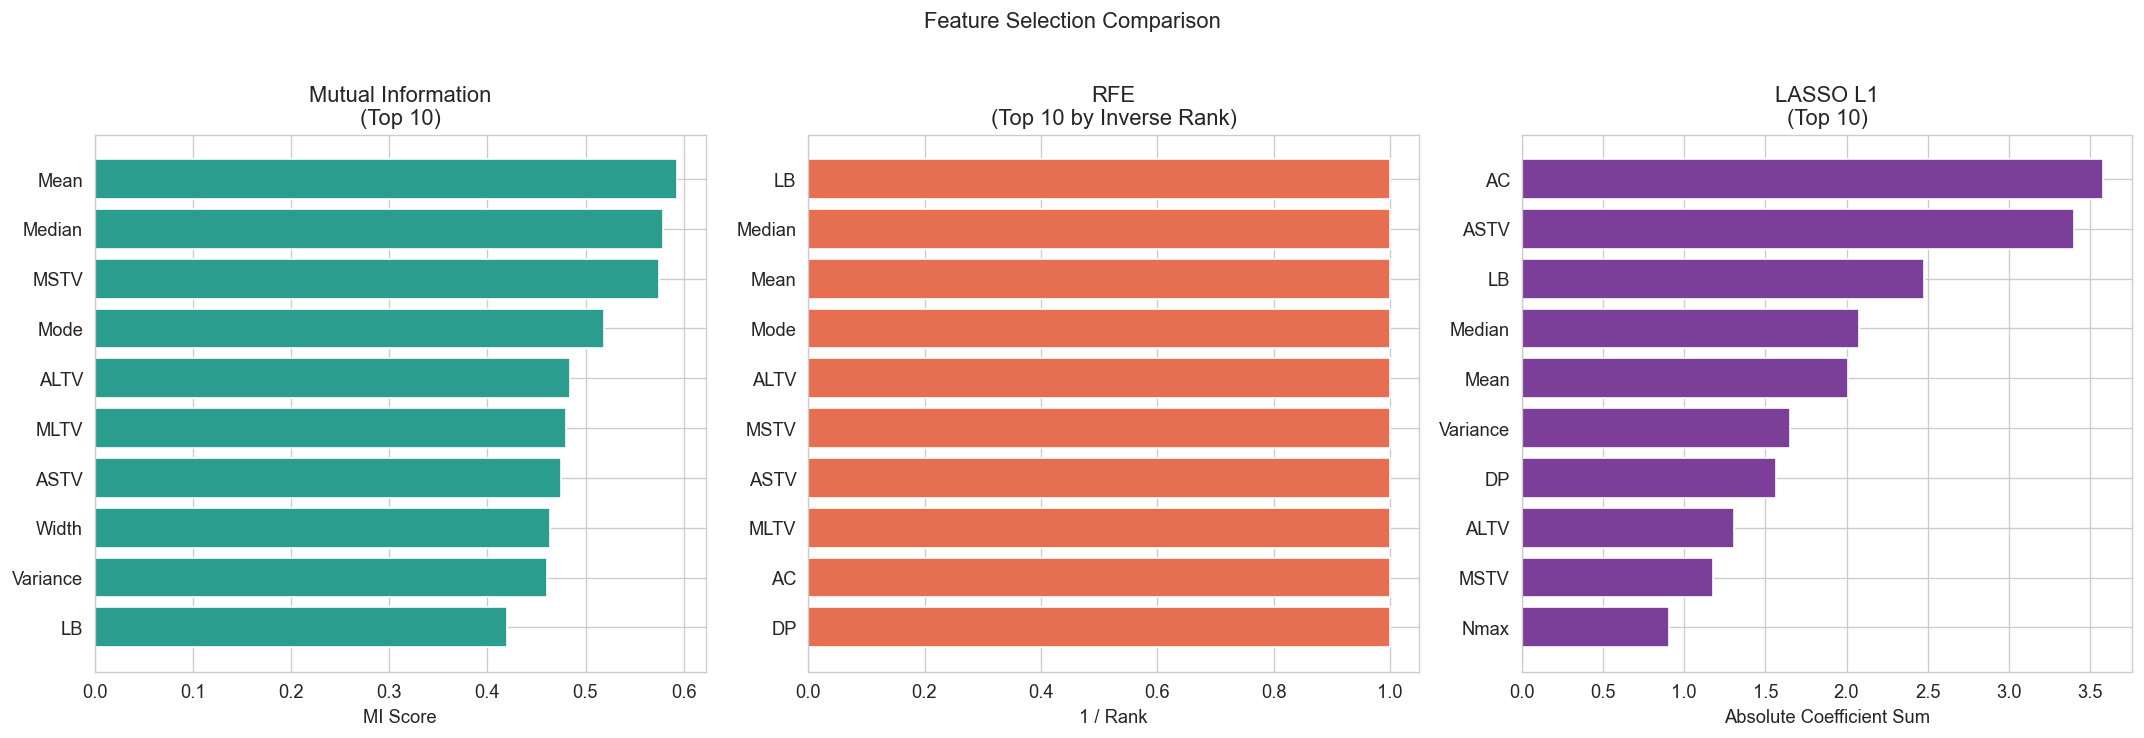

In [21]:
# PLOT 4: FEATURE SELECTION COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mutual Information — teal
mi_plot = mi_df.head(10)
axes[0].barh(
    mi_plot['Feature'],
    mi_plot['MI_Score'],
    color='#2a9d8f'
)
axes[0].set_title('Mutual Information\n(Top 10)')
axes[0].set_xlabel('MI Score')
axes[0].invert_yaxis()

# RFE — orange
rfe_plot = rfe_ranking.head(10)
axes[1].barh(
    rfe_plot['Feature'],
    1 / rfe_plot['Rank'],
    color='#e76f51'
)
axes[1].set_title('RFE\n(Top 10 by Inverse Rank)')
axes[1].set_xlabel('1 / Rank')
axes[1].invert_yaxis()

# LASSO — purple
lasso_plot = lasso_df.head(10)
axes[2].barh(
    lasso_plot['Feature'],
    lasso_plot['LASSO_Coef'],
    color='#7b3f99'
)
axes[2].set_title('LASSO L1\n(Top 10)')
axes[2].set_xlabel('Absolute Coefficient Sum')
axes[2].invert_yaxis()

plt.suptitle("Feature Selection Comparison", y=1.02)
plt.tight_layout()
plt.show()

In [22]:
#MODEL TRAINING & HYPERPARAMETER TUNING (3-CLASS, ALL FEATURES)

In [23]:
print("\n" + "="*60)
print("6. MODEL TRAINING — 3-CLASS (ALL FEATURES)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#Helper function
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, n_classes=3, fitted=False):
    """Train (if not fitted) and evaluate a classifier. Returns metrics dict."""
    if not fitted:
        model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_te, y_pred, average='macro', zero_division=0)

    if n_classes == 2:
        try:
            proba = model.predict_proba(X_te)[:, 1]
            auc = roc_auc_score(y_te, proba)
        except Exception:
            auc = np.nan
        spec = recall_score(y_te, y_pred, pos_label=0, zero_division=0)
    else:
        try:
            proba = model.predict_proba(X_te)
            classes = sorted(np.unique(y_te))
            y_bin  = label_binarize(y_te, classes=classes)
            auc = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan

        # Specificity: mean of per-class (TN/(TN+FP))
        cm = confusion_matrix(y_te, y_pred)
        specs = []
        for i in range(len(cm)):
            tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
            fp = cm[:, i].sum() - cm[i, i]
            specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        spec = np.mean(specs)

    print(f"\n[{name}]")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Macro F1   : {f1:.4f}")
    print(f"  Sensitivity: {sens:.4f}")
    print(f"  Specificity: {spec:.4f}")
    print(f"  ROC-AUC    : {auc:.4f}")
    print(classification_report(y_te, y_pred, zero_division=0))

    return {'Model': name, 'Accuracy': acc, 'F1': f1,
            'Sensitivity': sens, 'Specificity': spec, 'AUC': auc,
            'y_pred': y_pred, 'model': model}

#Logistic Regression
lr_params = {'C': [0.01, 0.1, 1, 10]}
lr_gs = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE,
                       multi_class='multinomial', solver='lbfgs'),
    lr_params, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1
)
lr_gs.fit(X_train_sm, y_train_sm)
print(f"Logistic Regression best C: {lr_gs.best_params_}")

#SVM
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
svm_gs = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    svm_params, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1
)
svm_gs.fit(X_train_sm, y_train_sm)
print(f"SVM best params: {svm_gs.best_params_}")

#6c. Random Forest
rf_params = {'n_estimators': [100, 200],
             'max_depth': [None, 10, 20],
             'min_samples_split': [2, 5]}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1
)
rf_gs.fit(X_train_sm, y_train_sm)
print(f"Random Forest best params: {rf_gs.best_params_}")

#XGBoost
xgb_params = {'n_estimators': [100, 200],
              'max_depth': [3, 6],
              'learning_rate': [0.05, 0.1]}
xgb_gs = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                  random_state=RANDOM_STATE, verbosity=0),
    xgb_params, cv=cv, scoring='roc_auc_ovr_weighted', n_jobs=-1
)
xgb_gs.fit(X_train_sm, y_train_sm)
print(f"XGBoost best params: {xgb_gs.best_params_}")

#Evaluate all models and store results
results_multi = []
for name, gs in [('Logistic Regression', lr_gs),
                 ('SVM', svm_gs),
                 ('Random Forest', rf_gs),
                 ('XGBoost', xgb_gs)]:
    r = evaluate_model(name, gs.best_estimator_,
                       X_train_sm, y_train_sm,
                       X_test_scaled_m, y_test_m,
                       n_classes=3, fitted=True)
    r['Dataset'] = 'Multi (all features)'
    results_multi.append(r)

print("\nAll models evaluated. results_multi is now defined.")



6. MODEL TRAINING — 3-CLASS (ALL FEATURES)
Logistic Regression best C: {'C': 1}
SVM best params: {'C': 10, 'gamma': 'auto'}
Random Forest best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
XGBoost best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

[Logistic Regression]
  Accuracy   : 0.8685
  Macro F1   : 0.7836
  Sensitivity: 0.8416
  Specificity: 0.9366
  ROC-AUC    : 0.9562
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       332
           1       0.55      0.81      0.66        59
           2       0.71      0.83      0.76        35

    accuracy                           0.87       426
   macro avg       0.75      0.84      0.78       426
weighted avg       0.90      0.87      0.88       426


[SVM]
  Accuracy   : 0.8967
  Macro F1   : 0.8217
  Sensitivity: 0.8350
  Specificity: 0.9234
  ROC-AUC    : 0.9754
              precision    recall  f1-score   support

           0      

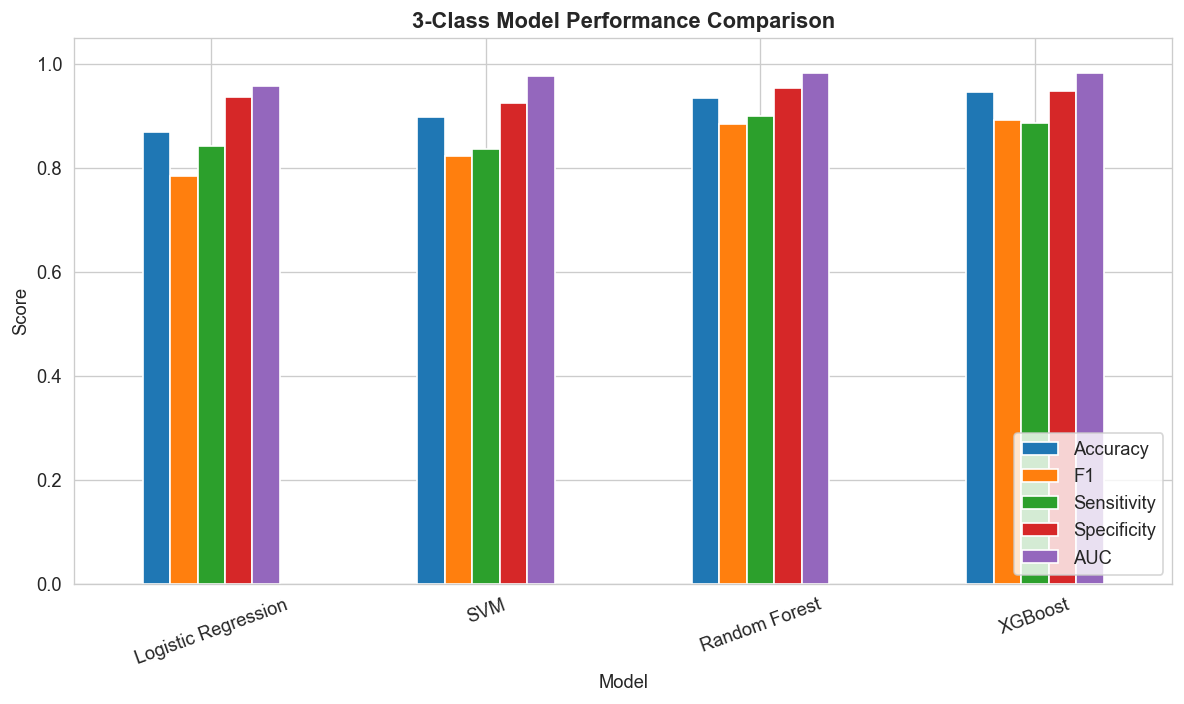

In [24]:
#PLOT 5: Model comparison (3-class all features) ───────────────────────
results_df = pd.DataFrame(results_multi)

metrics = ['Accuracy', 'F1', 'Sensitivity', 'Specificity', 'AUC']

fig, ax = plt.subplots(figsize=(10, 6))

results_df.set_index('Model')[metrics].plot(
    kind='bar',
    ax=ax
)

ax.set_title('3-Class Model Performance Comparison',
             fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [25]:
#MODEL TRAINING; BINARY (ALL FEATURES)

In [26]:
print("\n" + "="*60)
print("7. MODEL TRAINING — BINARY (ALL FEATURES)")
print("="*60)

results_binary = []
for name, clf in [
    ('Logistic Regression',
     LogisticRegression(C=lr_gs.best_params_['C'], max_iter=5000,
                        random_state=RANDOM_STATE, solver='lbfgs')),
    ('SVM',
     SVC(kernel='rbf', C=svm_gs.best_params_['C'],
         gamma=svm_gs.best_params_['gamma'],
         probability=True, random_state=RANDOM_STATE)),
    ('Random Forest',
     RandomForestClassifier(**rf_gs.best_params_, random_state=RANDOM_STATE)),
    ('XGBoost',
     XGBClassifier(**xgb_gs.best_params_, use_label_encoder=False,
                   eval_metric='logloss', random_state=RANDOM_STATE,
                   verbosity=0))]:
    r = evaluate_model(name, clf, X_train_sm_b, y_train_sm_b,
                       X_test_scaled_b, y_test_b, n_classes=2)
    r['Dataset'] = 'Binary (all features)'
    results_binary.append(r)


7. MODEL TRAINING — BINARY (ALL FEATURES)

[Logistic Regression]
  Accuracy   : 0.8803
  Macro F1   : 0.8477
  Sensitivity: 0.9041
  Specificity: 0.9468
  ROC-AUC    : 0.9543
              precision    recall  f1-score   support

           0       0.66      0.95      0.78        94
           1       0.98      0.86      0.92       332

    accuracy                           0.88       426
   macro avg       0.82      0.90      0.85       426
weighted avg       0.91      0.88      0.89       426


[SVM]
  Accuracy   : 0.9413
  Macro F1   : 0.9186
  Sensitivity: 0.9395
  Specificity: 0.9362
  ROC-AUC    : 0.9830
              precision    recall  f1-score   support

           0       0.82      0.94      0.88        94
           1       0.98      0.94      0.96       332

    accuracy                           0.94       426
   macro avg       0.90      0.94      0.92       426
weighted avg       0.95      0.94      0.94       426


[Random Forest]
  Accuracy   : 0.9507
  Macro F1   :

In [27]:
#REDUCED FEATURE SET; 3-CLASS

In [28]:
print("\n" + "="*60)
print("8. REDUCED FEATURE SET — 3-CLASS")
print("="*60)

results_reduced = []

for name, clf in [
    ('Logistic Regression',
     LogisticRegression(C=lr_gs.best_params_['C'], max_iter=5000,
                        random_state=RANDOM_STATE,
                        multi_class='multinomial', solver='lbfgs')),
    ('SVM',
     SVC(kernel='rbf', C=svm_gs.best_params_['C'],
         gamma=svm_gs.best_params_['gamma'],
         probability=True, random_state=RANDOM_STATE)),
    ('Random Forest',
     RandomForestClassifier(**rf_gs.best_params_, random_state=RANDOM_STATE))]:

    r = evaluate_model(name, clf, X_train_cs, y_train_sm,
                       X_test_cs, y_test_m, n_classes=3)
    r['Dataset'] = 'Multi (reduced features)'
    results_reduced.append(r)


8. REDUCED FEATURE SET — 3-CLASS

[Logistic Regression]
  Accuracy   : 0.8474
  Macro F1   : 0.7678
  Sensitivity: 0.8325
  Specificity: 0.9284
  ROC-AUC    : 0.9481
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       332
           1       0.49      0.81      0.62        59
           2       0.72      0.83      0.77        35

    accuracy                           0.85       426
   macro avg       0.73      0.83      0.77       426
weighted avg       0.89      0.85      0.86       426


[SVM]
  Accuracy   : 0.9085
  Macro F1   : 0.8582
  Sensitivity: 0.8935
  Specificity: 0.9490
  ROC-AUC    : 0.9728
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       332
           1       0.63      0.85      0.72        59
           2       0.89      0.91      0.90        35

    accuracy                           0.91       426
   macro avg       0.83      0.89      0.86       426
weighted 

In [29]:
# Reduced feature set applying XGBoost 
xgb_reduced = XGBClassifier(**xgb_gs.best_params_, use_label_encoder=False,
                            eval_metric='mlogloss', random_state=RANDOM_STATE,
                            verbosity=0)

r = evaluate_model('XGBoost', xgb_reduced, X_train_cs, y_train_sm,
                   X_test_cs, y_test_m, n_classes=3)
r['Dataset'] = 'Multi (reduced features)'
results_reduced.append(r)



[XGBoost]
  Accuracy   : 0.9413
  Macro F1   : 0.8915
  Sensitivity: 0.8975
  Specificity: 0.9486
  ROC-AUC    : 0.9813
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       332
           1       0.85      0.78      0.81        59
           2       0.85      0.94      0.89        35

    accuracy                           0.94       426
   macro avg       0.89      0.90      0.89       426
weighted avg       0.94      0.94      0.94       426



In [30]:
#ROBUSTNESS CHECK: Train on Extreme Cases → Test on Suspect


9. ROBUSTNESS CHECK: Extreme Cases (Normal vs Pathologic)
Extreme training samples: 3310

Suspect samples: 295
  Predicted as Pathologic: 112 (38.0%)
  Predicted as Normal    : 183 (62.0%)

Mean predicted pathology probability: 0.385


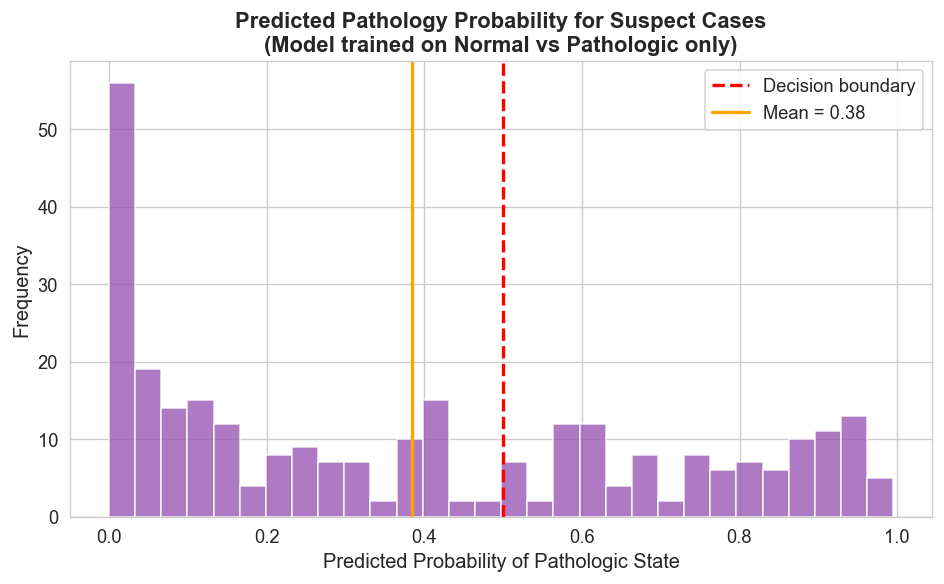

In [31]:
print("\n" + "="*60)
print("9. ROBUSTNESS CHECK: Extreme Cases (Normal vs Pathologic)")
print("="*60)

# Keep only Normal (0) and Pathologic (2) — drop Suspect (1)
extreme_mask = y_multi_encoded.isin([0, 2])
X_extreme = X_clean[extreme_mask]
y_extreme  = y_multi_encoded[extreme_mask]

# Remap to binary: 0=Normal, 1=Pathologic
y_extreme_bin = (y_extreme == 2).astype(int)

scaler_ex = StandardScaler()
X_extreme_scaled = scaler_ex.fit_transform(X_extreme)

smote_ex = SMOTE(random_state=RANDOM_STATE)
X_ex_sm, y_ex_sm = smote_ex.fit_resample(X_extreme_scaled, y_extreme_bin)

print(f"Extreme training samples: {len(X_ex_sm)}")

# Train RF on extreme cases
rf_extreme = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_extreme.fit(X_ex_sm, y_ex_sm)

# Apply to Suspect cases
suspect_mask = (y_multi_encoded == 1)
X_suspect    = X_clean[suspect_mask]
X_suspect_scaled = scaler_ex.transform(X_suspect)
y_suspect_pred   = rf_extreme.predict(X_suspect_scaled)
y_suspect_proba  = rf_extreme.predict_proba(X_suspect_scaled)[:, 1]

n_suspect = len(X_suspect)
n_pred_path = (y_suspect_pred == 1).sum()
n_pred_norm = (y_suspect_pred == 0).sum()

print(f"\nSuspect samples: {n_suspect}")
print(f"  Predicted as Pathologic: {n_pred_path} ({100*n_pred_path/n_suspect:.1f}%)")
print(f"  Predicted as Normal    : {n_pred_norm} ({100*n_pred_norm/n_suspect:.1f}%)")
print(f"\nMean predicted pathology probability: {y_suspect_proba.mean():.3f}")

# ── PLOT 5: Suspect probability distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_suspect_proba, bins=30, color='#9b59b6', edgecolor='white', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision boundary')
ax.axvline(y_suspect_proba.mean(), color='orange', linestyle='-',
           linewidth=2, label=f'Mean = {y_suspect_proba.mean():.2f}')
ax.set_xlabel('Predicted Probability of Pathologic State', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Predicted Pathology Probability for Suspect Cases\n'
             '(Model trained on Normal vs Pathologic only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
#PLOTS; CONFUSION MATRICES, ROC CURVES


10. VISUALISATIONS


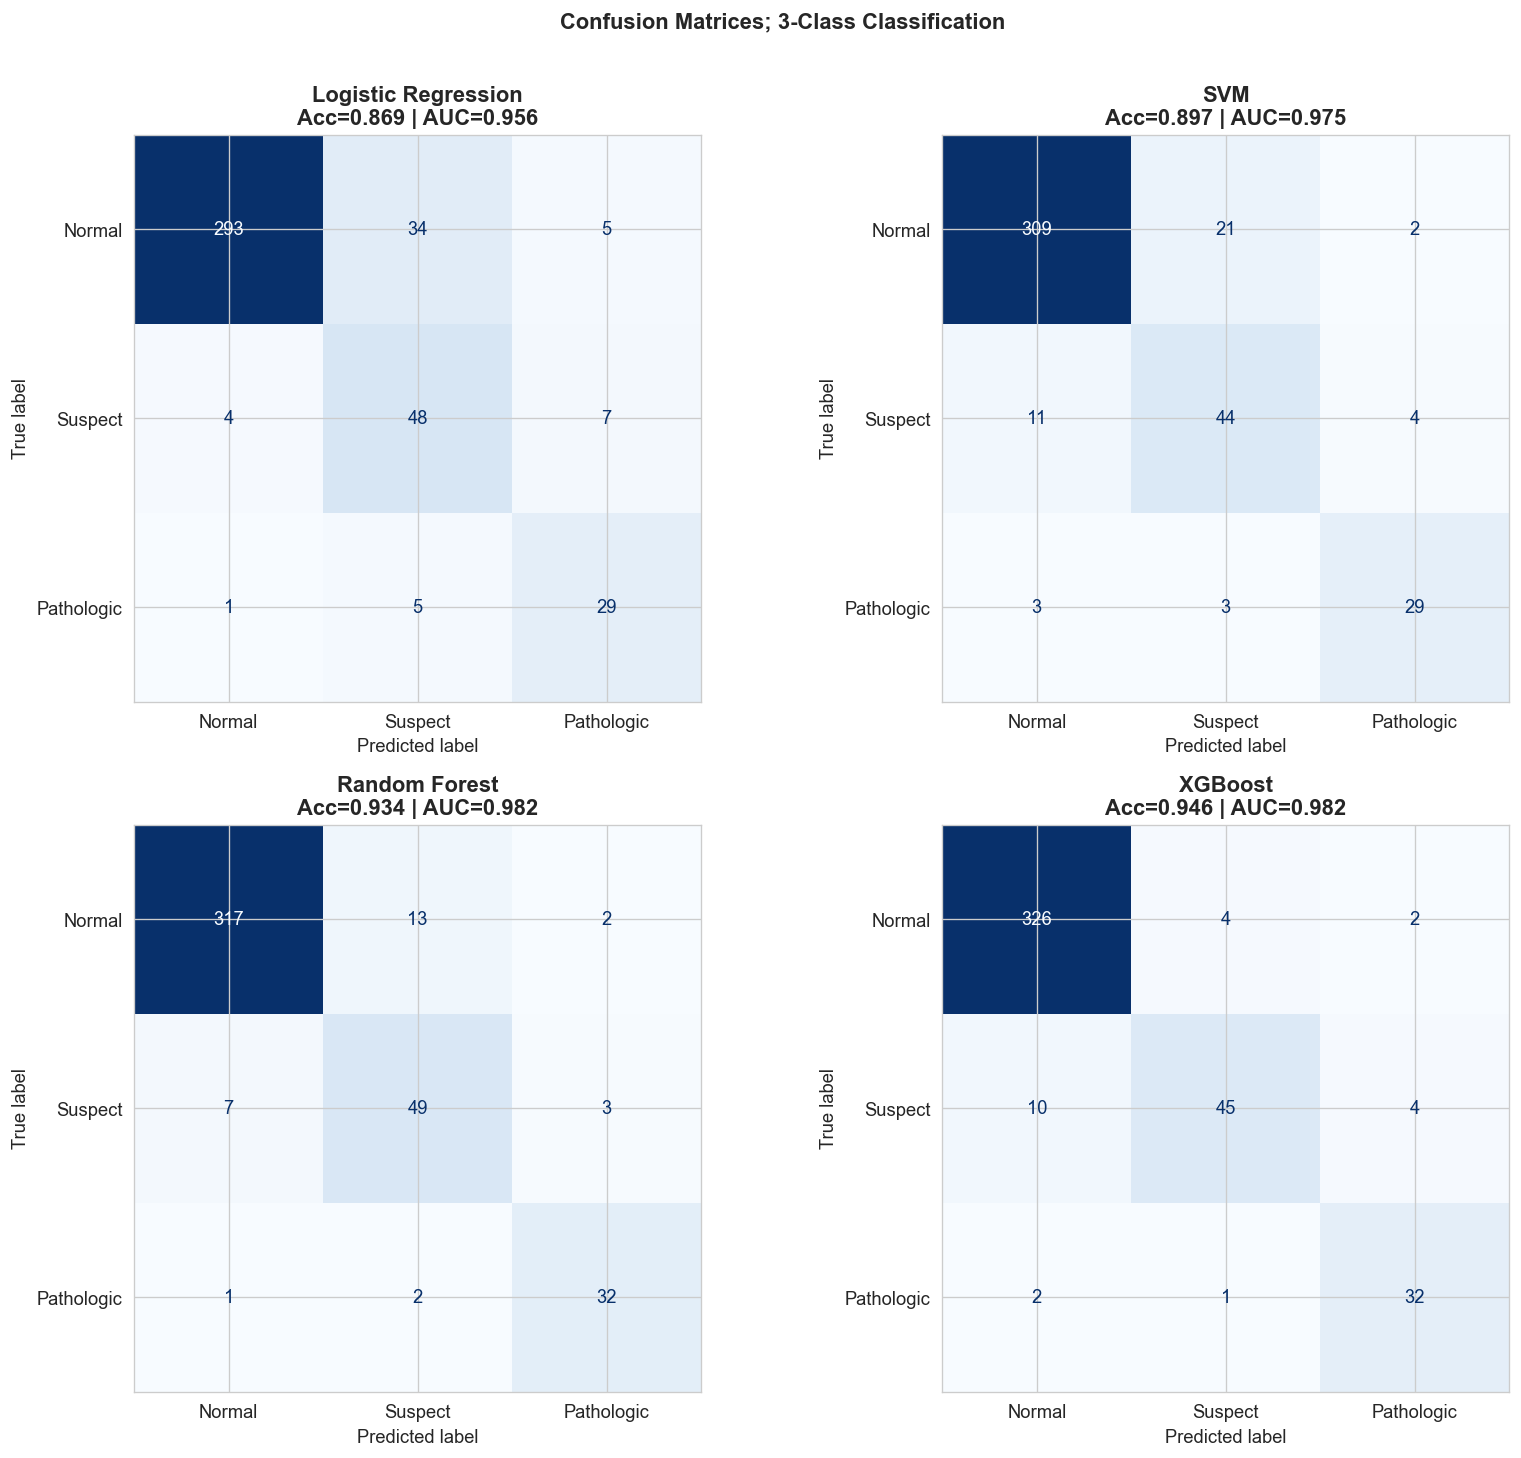

In [33]:
# =============================================================================
print("\n" + "="*60)
print("10. VISUALISATIONS")
print("="*60)

class_names_3 = ['Normal', 'Suspect', 'Pathologic']
class_names_2 = ['Abnormal', 'Normal']

# ── PLOT 6: Confusion matrices — 3-class
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
for i, r in enumerate(results_multi):
    cm = confusion_matrix(y_test_m, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names_3)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{r['Model']}\nAcc={r['Accuracy']:.3f} | AUC={r['AUC']:.3f}",
                      fontweight='bold')
plt.suptitle('Confusion Matrices; 3-Class Classification',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

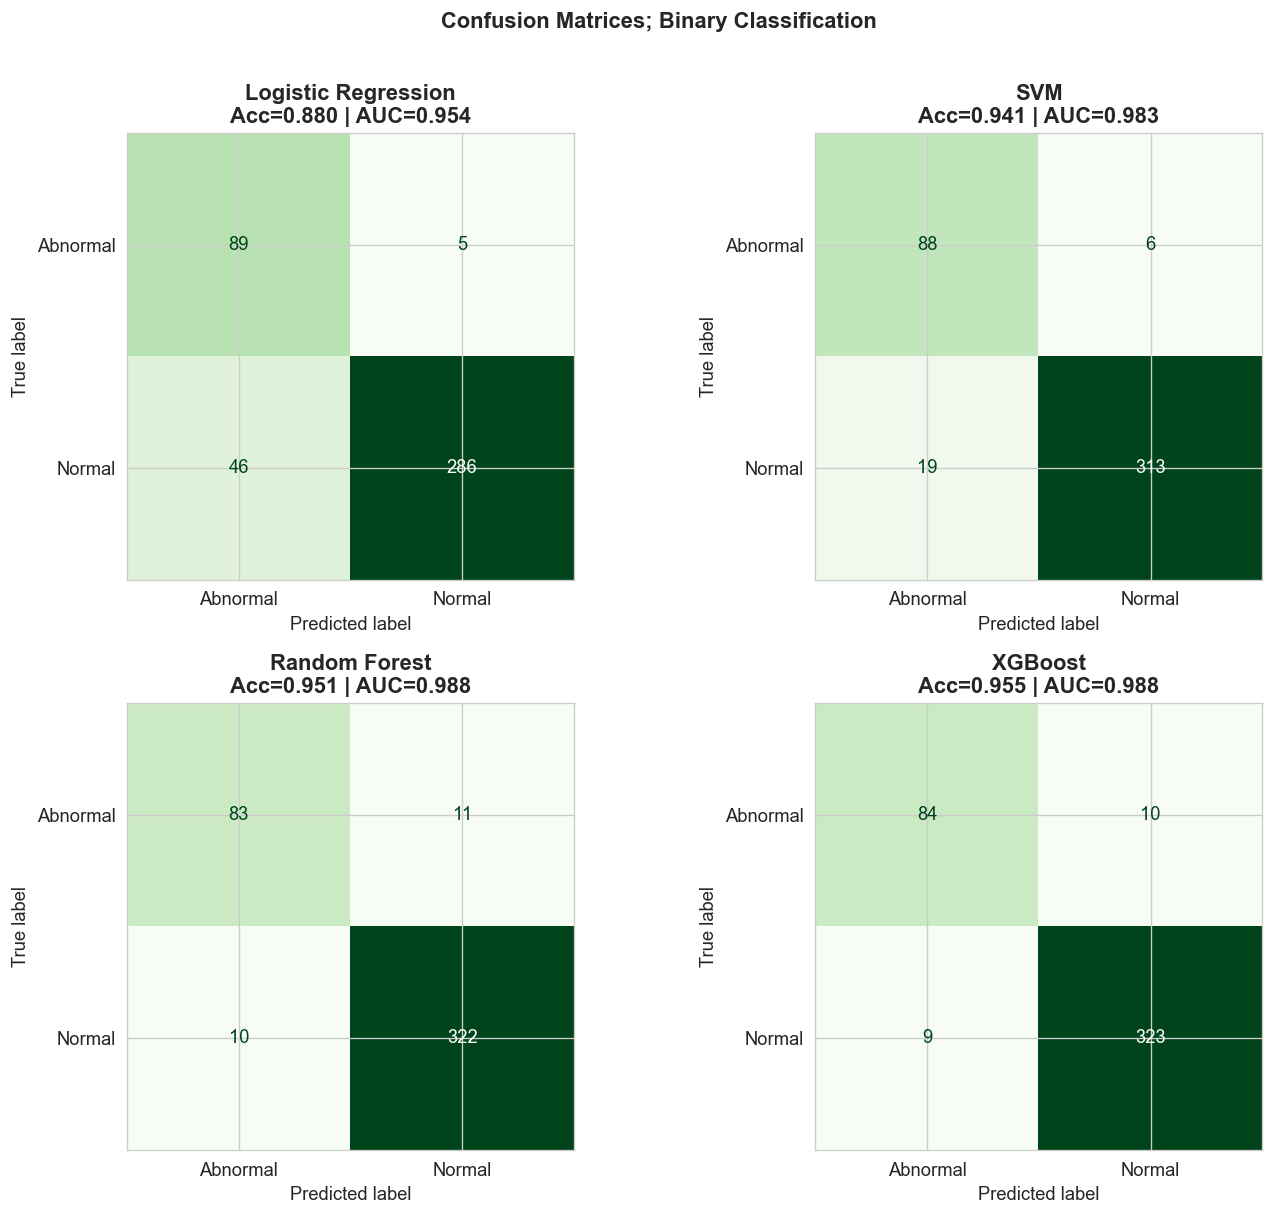

In [34]:
#Confusion matrices; binary
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, r in enumerate(results_binary):
    cm = confusion_matrix(y_test_b, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names_2)
    disp.plot(ax=axes[i], colorbar=False, cmap='Greens')
    axes[i].set_title(f"{r['Model']}\nAcc={r['Accuracy']:.3f} | AUC={r['AUC']:.3f}",
                      fontweight='bold')
plt.suptitle('Confusion Matrices; Binary Classification',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

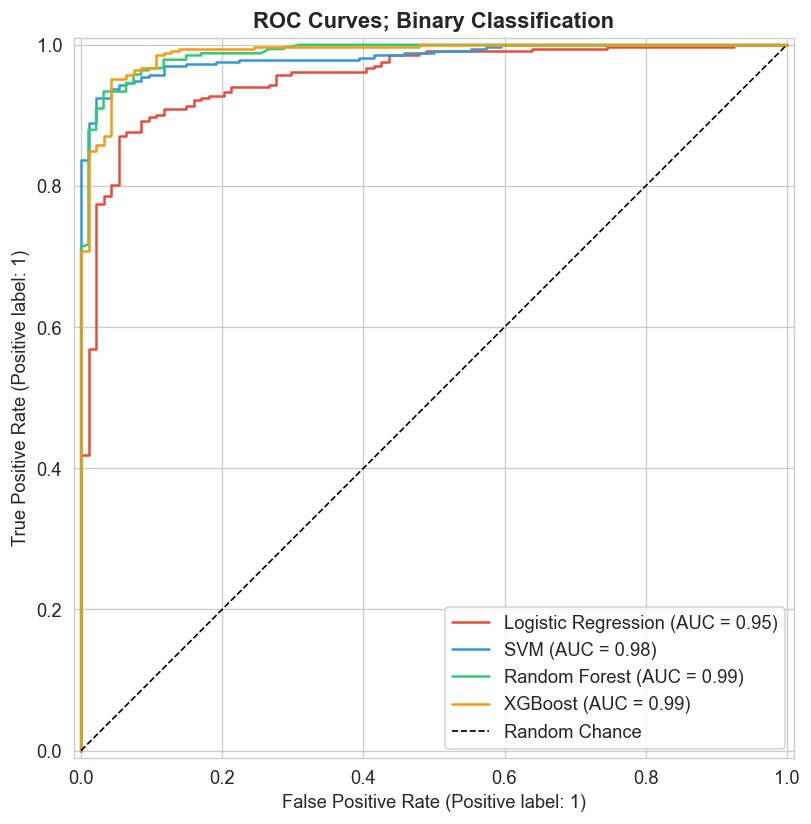

In [43]:
# ROC Curves; binary 
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for r, color in zip(results_binary, colors):
    try:
        proba = r['model'].predict_proba(X_test_scaled_b)[:, 1]
        RocCurveDisplay.from_predictions(y_test_b, proba,
                                         name=r['Model'],
                                         ax=ax, color=color)
    except Exception:
        pass
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Chance')
ax.set_title('ROC Curves; Binary Classification', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

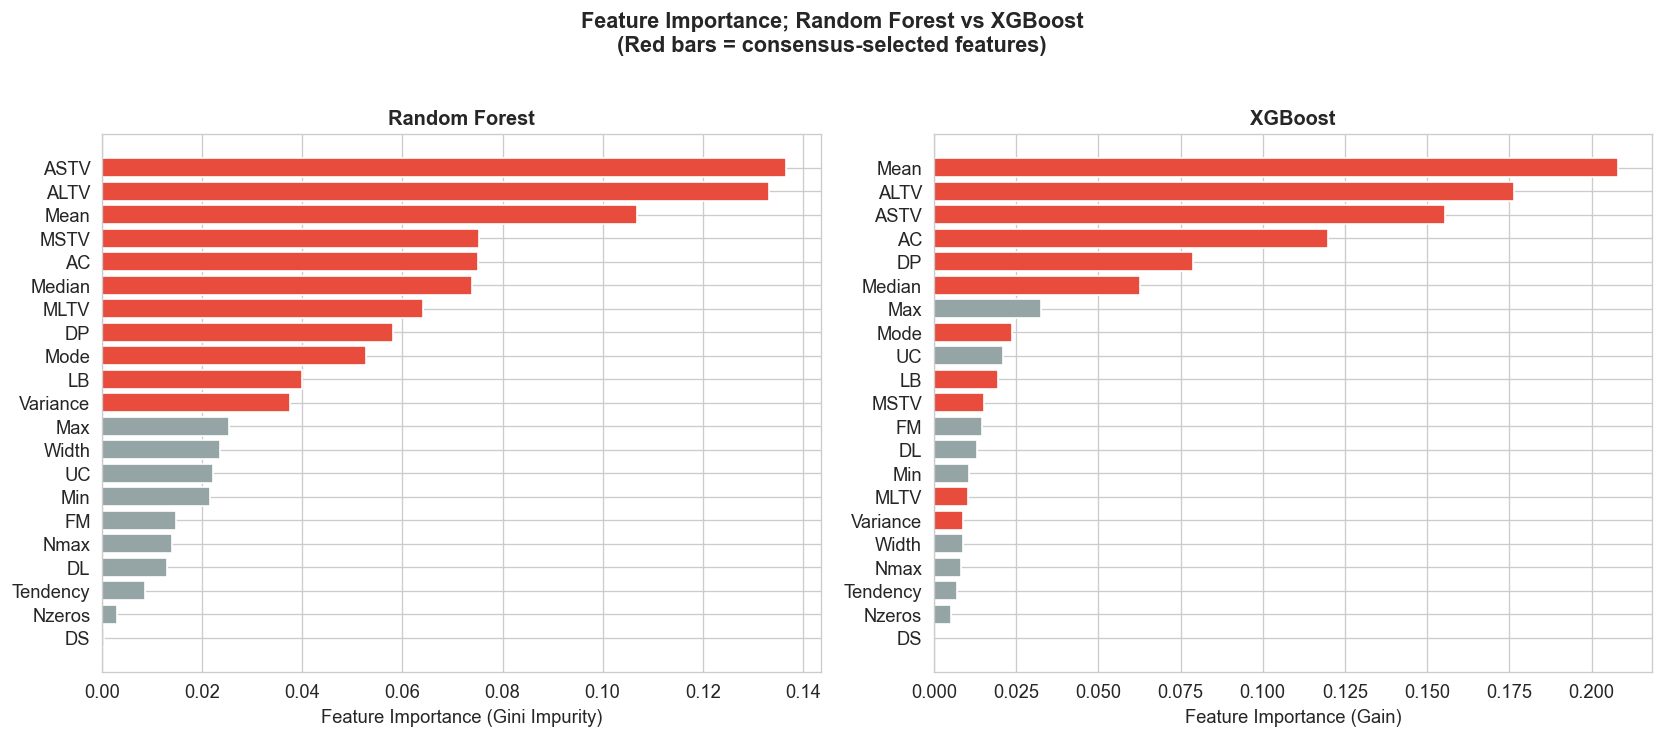

In [36]:
#Combined feature importance; Random Forest vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# Random Forest panel
rf_imp = pd.Series(rf_gs.best_estimator_.feature_importances_,
                   index=feature_names).sort_values(ascending=True)
colors_rf = ['#e74c3c' if f in consensus_features else '#95a5a6'
             for f in rf_imp.index]
axes[0].barh(rf_imp.index, rf_imp.values, color=colors_rf)
axes[0].set_title('Random Forest', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Importance (Gini Impurity)')

# XGBoost panel
xgb_imp = pd.Series(xgb_gs.best_estimator_.feature_importances_,
                    index=feature_names).sort_values(ascending=True)
colors_xgb = ['#e74c3c' if f in consensus_features else '#95a5a6'
              for f in xgb_imp.index]
axes[1].barh(xgb_imp.index, xgb_imp.values, color=colors_xgb)
axes[1].set_title('XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Importance (Gain)')

fig.suptitle('Feature Importance; Random Forest vs XGBoost\n'
             '(Red bars = consensus-selected features)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [38]:
#RESULTS TABLE
print("\n" + "="*60)
print("11. RESULTS SUMMARY TABLE")
print("="*60)

all_results = []
for r in results_multi + results_binary + results_reduced:
    all_results.append({
        'Dataset':     r['Dataset'],
        'Model':       r['Model'],
        'Accuracy':    round(r['Accuracy'], 4),
        'Macro F1':    round(r['F1'], 4),
        'Sensitivity': round(r['Sensitivity'], 4),
        'Specificity': round(r['Specificity'], 4),
        'ROC-AUC':     round(r['AUC'], 4)
    })

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))



11. RESULTS SUMMARY TABLE
                 Dataset               Model  Accuracy  Macro F1  Sensitivity  Specificity  ROC-AUC
    Multi (all features) Logistic Regression    0.8685    0.7836       0.8416       0.9366   0.9562
    Multi (all features)                 SVM    0.8967    0.8217       0.8350       0.9234   0.9754
    Multi (all features)       Random Forest    0.9343    0.8835       0.8999       0.9537   0.9821
    Multi (all features)             XGBoost    0.9460    0.8918       0.8863       0.9478   0.9819
   Binary (all features) Logistic Regression    0.8803    0.8477       0.9041       0.9468   0.9543
   Binary (all features)                 SVM    0.9413    0.9186       0.9395       0.9362   0.9830
   Binary (all features)       Random Forest    0.9507    0.9281       0.9264       0.8830   0.9882
   Binary (all features)             XGBoost    0.9554    0.9349       0.9333       0.8936   0.9881
Multi (reduced features) Logistic Regression    0.8474    0.7678       0.

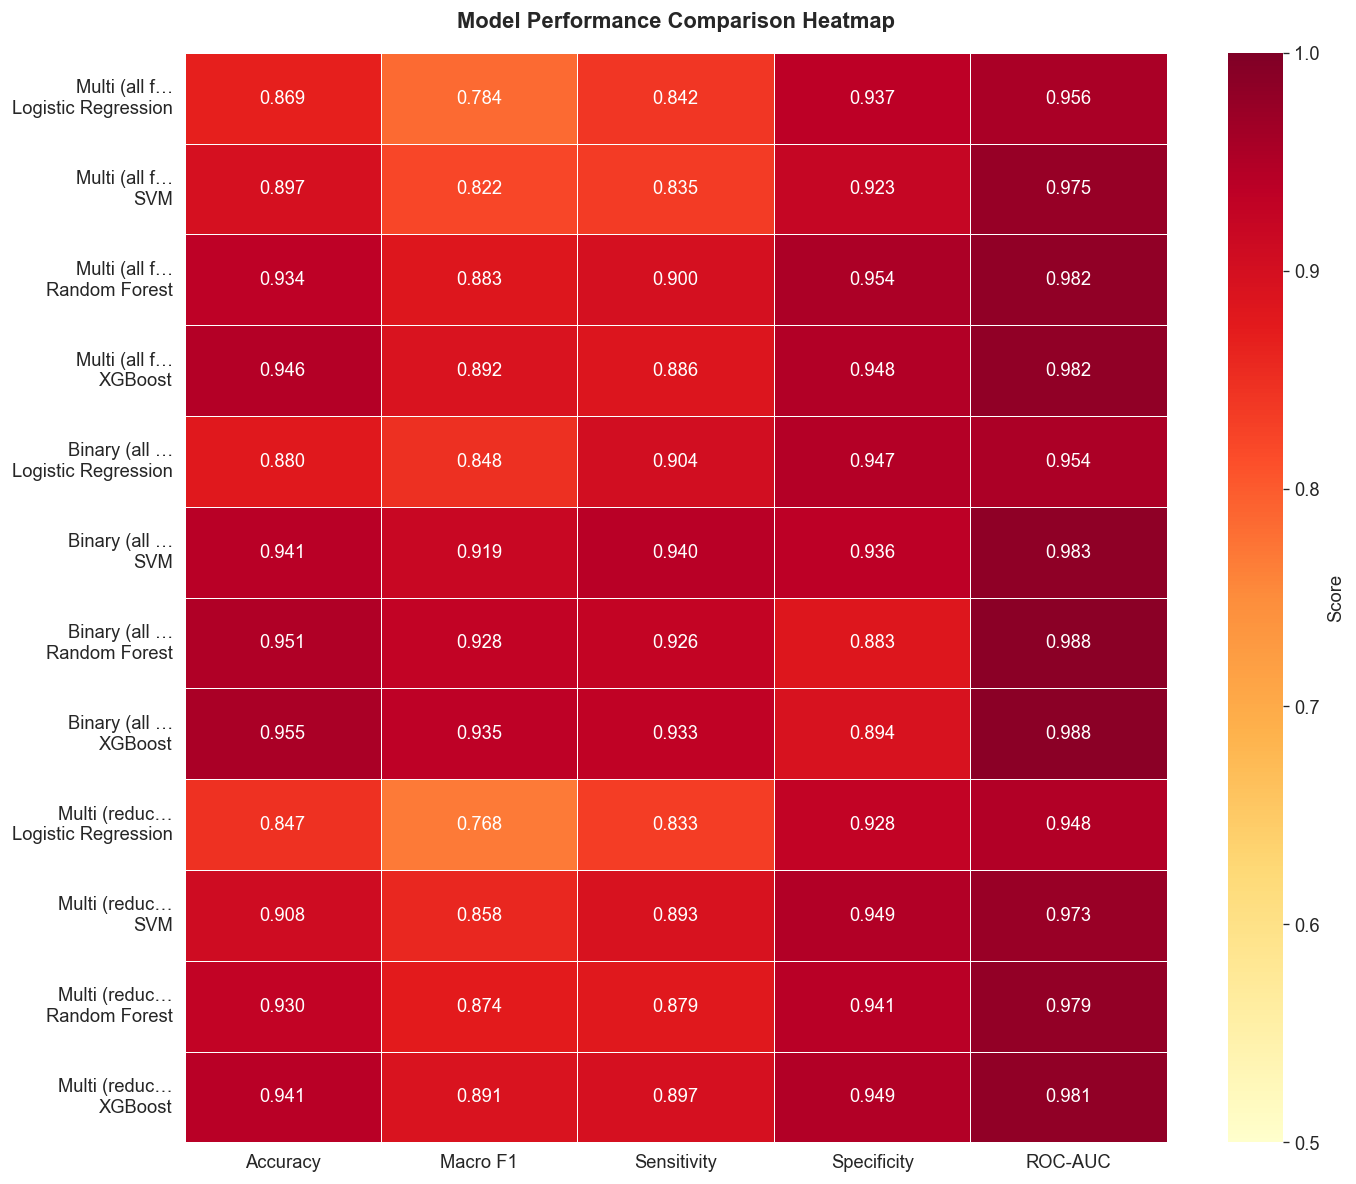

In [39]:
#Results comparison heatmap
metrics = ['Accuracy', 'Macro F1', 'Sensitivity', 'Specificity', 'ROC-AUC']
pivot_data = results_df.set_index(['Dataset', 'Model'])[metrics]
pivot_matrix = pivot_data.values

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot_matrix,
            xticklabels=metrics,
            yticklabels=[f"{r['Dataset'][:12]}…\n{r['Model']}"
                         for _, r in results_df.iterrows()],
            annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax.set_title('Model Performance Comparison Heatmap',
             fontweight='bold', pad=15)
plt.tight_layout()

plt.show()

In [40]:
#INTERPRETATION SUMMARY

In [42]:
print("\n" + "="*60)
print("12. INTERPRETATION SUMMARY")
print("="*60)

best_multi   = results_df[results_df['Dataset'].str.contains('Multi \(all')].sort_values('ROC-AUC', ascending=False).iloc[0]
best_binary  = results_df[results_df['Dataset'].str.contains('Binary')].sort_values('ROC-AUC', ascending=False).iloc[0]
best_reduced = results_df[results_df['Dataset'].str.contains('reduced')].sort_values('ROC-AUC', ascending=False).iloc[0]

print(f"\nBest 3-class model  : {best_multi['Model']}  → AUC={best_multi['ROC-AUC']}")
print(f"Best binary model   : {best_binary['Model']} → AUC={best_binary['ROC-AUC']}")
print(f"Best reduced model  : {best_reduced['Model']} → AUC={best_reduced['ROC-AUC']}")

print(f"\nTop 5 most predictive features (Random Forest):")
top5_rf = rf_imp.sort_values(ascending=False).head(5)
for i, (feat, imp) in enumerate(top5_rf.items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

print(f"\nConsensus features selected by ≥2 methods ({len(consensus_features)}):")
print(f"  {consensus_features}")

print(f"\nSuspect case analysis:")
print(f"  {n_pred_path}/{n_suspect} Suspect cases ({100*n_pred_path/n_suspect:.1f}%) "
      f"predicted Pathologic by model trained on extreme classes.")
print(f" This bimodal distribution suggests Suspect is a heterogeneous label rather than a uniform intermediate state.")


12. INTERPRETATION SUMMARY

Best 3-class model  : Random Forest  → AUC=0.9821
Best binary model   : Random Forest → AUC=0.9882
Best reduced model  : XGBoost → AUC=0.9813

Top 5 most predictive features (Random Forest):
  1. ASTV: 0.1367
  2. ALTV: 0.1333
  3. Mean: 0.1069
  4. MSTV: 0.0753
  5. AC: 0.0752

Consensus features selected by ≥2 methods (11):
  ['AC', 'ALTV', 'ASTV', 'DP', 'LB', 'MLTV', 'MSTV', 'Mean', 'Median', 'Mode', 'Variance']

Suspect case analysis:
  112/295 Suspect cases (38.0%) predicted Pathologic by model trained on extreme classes.
 This bimodal distribution suggests Suspect is a heterogeneous label rather than a uniform intermediate state.
